In [50]:
# Load libraries

import os
import pandas
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from scipy import stats
import sklearn.model_selection
import shutil

# import my extended pySuStaIn model
from apoe4_sustain import ZscoreSustain_APOE4
# import simulation function
from genetics_simulation_utils import genetics_simulation


1. Simulate biomarkers using zscore SuStaIn model and a categorical variable: APOE carrier status based on fixed genetic probabilities

In [51]:
# define hyper-parameters of simulation
# Configure dataset dimensions
M_patients = 1000
N_biomarkers = 5
N_subtypes = 2
gt_fractions = np.array([0.45, 0.55])

# Define the explicit ground-truth genetic profiles for this sandbox run
# W_true_target = np.array([
#     [0.80, 0.15, 0.05],  # Subtype 0: High Category 0 anchor
#     [0.10, 0.30, 0.60]   # Subtype 1: High Category 2 anchor
# ])

print("Sandbox parameters initialized.")

Sandbox parameters initialized.


In [52]:
# Uniform case
W_true_target = np.array([
    [1/3, 1/3, 1/3],  # Subtype 0: High Category 0 anchor
    [1/3, 1/3, 1/3]   # Subtype 1: High Category 2 anchor
])

print("Sandbox parameters initialized.")

Sandbox parameters initialized.


In [53]:
# Generate the dataset in-memory
df, Z_vals, Z_max, gt_ordering, W_true = genetics_simulation(
    N=N_biomarkers, 
    M=M_patients, 
    N_S_gt=N_subtypes, 
    gt_fractions=gt_fractions, 
    W_true=W_true_target, 
    use_midpoints=False, # Set to True if you want to test your supervisor's midpoint variant
    save=False
)

df

Generator(PCG64)
Rng from before


,Biomarker 0,Biomarker 1,Biomarker 2,Biomarker 3,Biomarker 4,ground_truth_subtypes,ground_truth_stages,apoe_status
0,1.801244,0.160651,-0.006831,-0.558096,-1.598514,0,0,2
1,-2.043287,-0.409780,0.014403,-2.107768,0.515172,0,0,0
2,0.588593,-0.603643,0.930676,-1.547924,1.244449,0,0,2
3,1.028134,-0.446928,-0.619910,1.190880,0.306396,0,0,0
4,0.670040,-1.132107,-1.003627,0.010623,-0.839534,0,0,2
...,...,...,...,...,...,...,...,...
995,-0.481166,-0.076745,4.562097,3.877157,1.782873,1,6,0
996,0.042566,5.368004,0.458147,0.633964,1.800887,2,8,2
997,-1.883136,-1.449575,1.958992,0.987868,1.464852,2,1,0
998,3.928200,3.497181,1.920660,2.287131,3.163869,2,12,2


In [54]:
# Extract raw arrays for the model execution
BiomarkerNames = [f'Biomarker {i}' for i in range(N_biomarkers)]
X_data = df[BiomarkerNames].values
y_genetics = df['apoe_status'].values

print(f"Generated data matrix shape: {X_data.shape}")
print(f"Generated genetic vector shape: {y_genetics.shape}")

Generated data matrix shape: (1000, 5)
Generated genetic vector shape: (1000,)


In [55]:
N_startpoints = 15
N_S_max = 2
N_iterations_MCMC = int(1e4)
#output_folder = os.path.join(os.getcwd(), 'MRI_Sustain_5features_all')



In [56]:
dataset_name = 'simulated_data_genetics_model'
output_folder = os.path.join(os.getcwd(), dataset_name)
sustain_input = ZscoreSustain_APOE4(X_data,
                                Z_vals,
                                Z_max,
                                BiomarkerNames,
                                N_startpoints,
                                N_subtypes, 
                                N_iterations_MCMC, 
                                output_folder, 
                                dataset_name, 
                                False,
                                apoe4_status = y_genetics,
                                #apoe4_status = gender_status_array,
                                apoe_flag = True)

1000 patients initially
 -> Detected 3 unique genetic categories: [0 1 2]
1000 patients with non null apoe4 carrier status
 -> [Genetics Setup] Global cohort background frequencies calculated: [0.31  0.337 0.353]
Running genetic weighted SuStaIn 


Run SuStaIn 

In [57]:
# delete previous pickle files
if os.path.exists(output_folder):
    shutil.rmtree(output_folder)

In [58]:
# make the output directory if it's not already created
if not os.path.isdir(output_folder):
    os.mkdir(output_folder)

In [59]:

ml_sequence_EM,     \
ml_f_EM,            \
ml_subtype,         \
prob_ml_subtype,    \
ml_stage,           \
prob_ml_stage,      \
prob_subtype_stage,         = sustain_input.run_sustain_algorithm()


Failed to find pickle file: /Users/mihaelacroitor/apoe4_informed/simulated_data_genetics_model/pickle_files/simulated_data_genetics_model_subtype0.pickle. Running SuStaIn model for 0 subtype.
Finding ML solution to 1 cluster problem
--- Upfront Anatomical Burn-In Complete (0 iterations) ---
Using combined method
EM converged in 3 iterations
--- Upfront Anatomical Burn-In Complete (0 iterations) ---
Using combined method
EM converged in 5 iterations
--- Upfront Anatomical Burn-In Complete (0 iterations) ---
Using combined method
EM converged in 3 iterations
--- Upfront Anatomical Burn-In Complete (0 iterations) ---
Using combined method
EM converged in 3 iterations
--- Upfront Anatomical Burn-In Complete (0 iterations) ---
Using combined method
EM converged in 4 iterations
--- Upfront Anatomical Burn-In Complete (0 iterations) ---
Using combined method
EM converged in 4 iterations
--- Upfront Anatomical Burn-In Complete (0 iterations) ---
Using combined method
EM converged in 4 iteratio

MCMC Iteration: 100%|██████████| 10000/10000 [00:05<00:00, 1836.43it/s]



   FINAL MODEL SUBTYPE COHORT FRACTIONS
 -> Subtype 1 Cohort Size: 100.00% of dataset

   SUSTAIN GENETIC PRIOR PROFILE (EM MAX LIKELIHOOD)
 -> COHORT BACKGROUND BASELINE : [Cat_0: 0.3100, Cat_1: 0.3370, Cat_2: 0.3530]
------------------------------------------------------------
 -> Subtype 1 Profile Prior : [Cat_0: 0.3100, Cat_1: 0.3370, Cat_2: 0.3530]

Failed to find pickle file: /Users/mihaelacroitor/apoe4_informed/simulated_data_genetics_model/pickle_files/simulated_data_genetics_model_subtype1.pickle. Running SuStaIn model for 1 subtype.
Splitting cluster 1 of 1
Reindexing
 + Resolving 2 cluster problem
--- Upfront Anatomical Burn-In Complete (0 iterations) ---
Using combined method
EM converged in 3 iterations
--- Upfront Anatomical Burn-In Complete (0 iterations) ---
Using combined method
EM converged in 3 iterations
--- Upfront Anatomical Burn-In Complete (0 iterations) ---
Using combined method
EM converged in 13 iterations
--- Upfront Anatomical Burn-In Complete (0 iteration

MCMC Iteration: 100%|██████████| 10000/10000 [00:14<00:00, 692.76it/s]



   FINAL MODEL SUBTYPE COHORT FRACTIONS
 -> Subtype 1 Cohort Size: 45.60% of dataset
 -> Subtype 2 Cohort Size: 54.40% of dataset

   SUSTAIN GENETIC PRIOR PROFILE (EM MAX LIKELIHOOD)
 -> COHORT BACKGROUND BASELINE : [Cat_0: 0.3100, Cat_1: 0.3370, Cat_2: 0.3530]
------------------------------------------------------------
 -> Subtype 1 Profile Prior : [Cat_0: 0.2965, Cat_1: 0.3527, Cat_2: 0.3508]
 -> Subtype 2 Profile Prior : [Cat_0: 0.3214, Cat_1: 0.3238, Cat_2: 0.3548]



In [60]:
ml_sequence_EM

array([[[ 1.,  1.,  1., ...,  1.,  1.,  1.],
        [ 4.,  4.,  4., ...,  2.,  2.,  2.],
        [ 2.,  2.,  2., ...,  4.,  4.,  4.],
        ...,
        [12., 12., 12., ..., 12., 12., 12.],
        [ 5.,  5.,  5., ...,  5.,  5.,  5.],
        [10., 10., 10., ..., 10., 10., 10.]],

       [[ 4.,  4.,  4., ...,  4.,  4.,  4.],
        [ 9.,  9.,  9., ...,  9.,  9.,  9.],
        [ 1.,  1.,  1., ...,  1.,  1.,  1.],
        ...,
        [12., 12., 12., ..., 12., 12., 12.],
        [13., 13., 13., ..., 13., 13., 13.],
        [14., 14., 14., ..., 14., 14., 14.]]], shape=(2, 15, 10000))

### Proof 1 Does the model recover correct params?

In [61]:
W_true_target

array([[0.33333333, 0.33333333, 0.33333333],
       [0.33333333, 0.33333333, 0.33333333]])

In [62]:
## Plot sequences

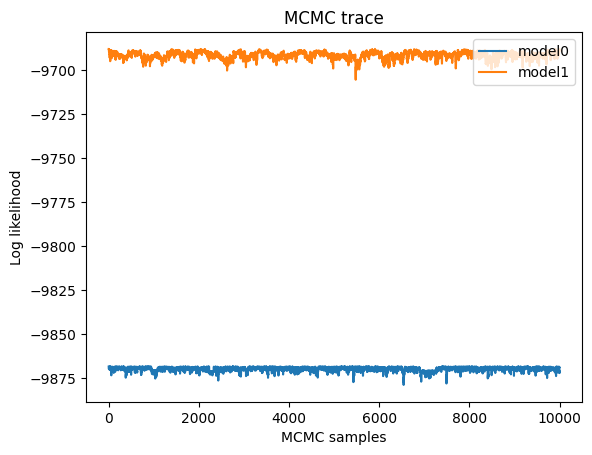

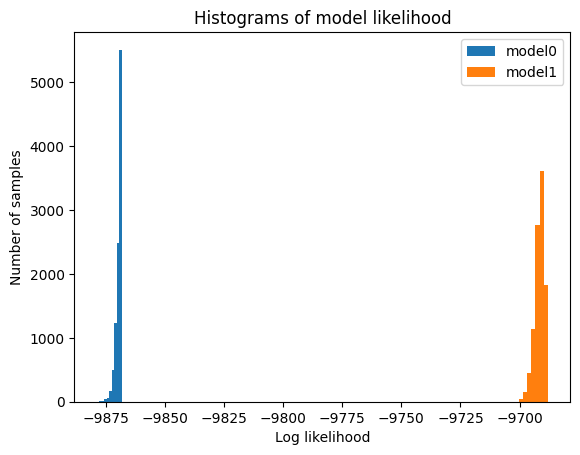

In [63]:
# for each subtype model
for s in range(N_S_max):
    # load pickle file (SuStaIn output) and get the sample log likelihood values
    pickle_filename_s = output_folder + '/pickle_files/' + dataset_name + '_subtype' + str(s) + '.pickle'
    pk = pandas.read_pickle(pickle_filename_s)
    samples_likelihood = pk["samples_likelihood"]
    
    # plot the values as a line plot
    fig0 = plt.figure(0)
    plt.plot(range(N_iterations_MCMC), samples_likelihood, label="model" + str(s))
    plt.legend(loc='upper right')
    plt.xlabel('MCMC samples')
    plt.ylabel('Log likelihood')
    plt.title('MCMC trace')
    
    # plot the values as a histogramp plot
    fig1 = plt.figure(1)
    plt.hist(samples_likelihood, label="model" + str(s))
    plt.legend(loc='upper right')
    plt.xlabel('Log likelihood')  
    plt.ylabel('Number of samples')  
    plt.title('Histograms of model likelihood')
fig0.savefig(output_folder+'/mcmc_trace.png')
fig1.savefig(output_folder+'/mcmc_histogram.png')


0
[1.]
[0]
1
[0.54331117 0.45668883]
[1 0]


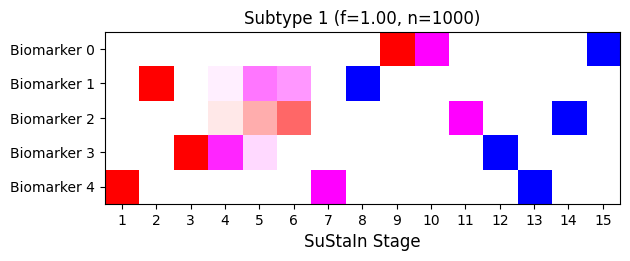

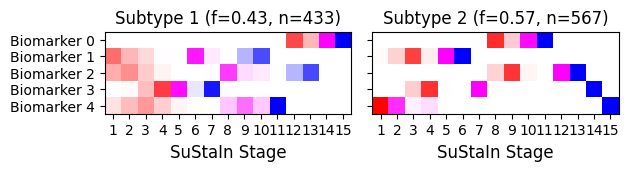

In [77]:

for s in range(N_S_max):
    print(s)
    #s = 1 # 1 split = 2 subtypes
    M = len(X_data) 

    # get the sample sequences and f
    pickle_filename_s = output_folder + '/pickle_files/' + dataset_name + '_subtype' + str(s) + '.pickle'
    pk = pandas.read_pickle(pickle_filename_s)
    samples_sequence = pk["samples_sequence"]
    samples_f = pk["samples_f"]
    ml_f_EM = pk["ml_f_EM"]
    print(ml_f_EM)
    if use_outlier:
        subtype_order = np.argsort(ml_f_EM[:-1])
    else:
        subtype_order = np.argsort(ml_f_EM)
    print(subtype_order)
    # use this information to plot the positional variance diagrams
    tmp=ZscoreSustain_APOE4._plot_sustain_model(sustain_input,samples_sequence,samples_f,M,subtype_order=subtype_order,biomarker_labels=BiomarkerNames)
    plt.savefig(output_folder + f"/pos_var_diagrams{s}.png")

Plot actual sequences


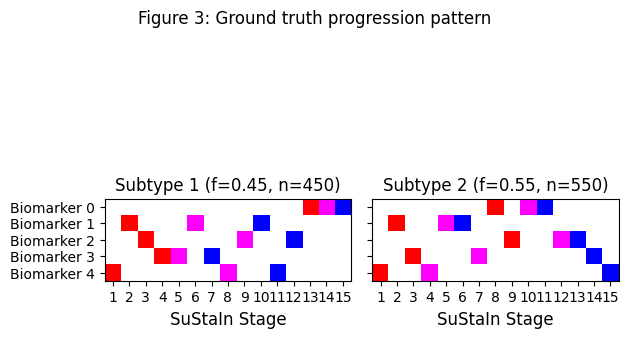

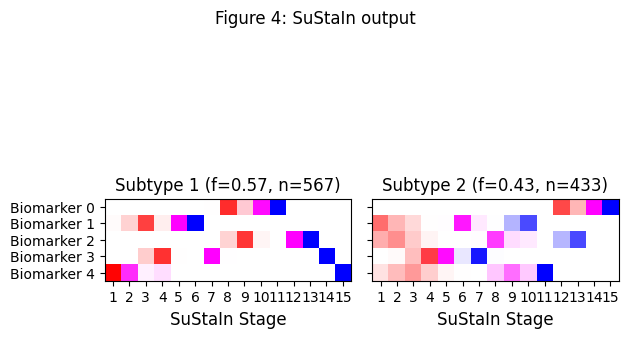

In [ ]:
# Output a figure showing the ground truth
gt_sequence = gt_ordering
gt_f        = gt_fractions
temp_gt_sequence = np.tile(np.reshape(gt_sequence,(gt_sequence.shape[0],gt_sequence.shape[1],1)),100)
temp_gt_f = np.asarray(gt_f).reshape(len(gt_f),1)
ZscoreSustain_APOE4._plot_sustain_model(sustain_input,temp_gt_sequence,temp_gt_f,M,subtype_order=(0,1))
_ = plt.suptitle('Figure 3: Ground truth progression pattern')

# The code below opens the results for the ground truth number of subtypes
# and plots the output
s = N_S_max-1
pickle_filename_s = output_folder + '/pickle_files/' + dataset_name + '_subtype' + str(s) + '.pickle'
pk = pandas.read_pickle(pickle_filename_s)
samples_sequence            = pk["samples_sequence"]
samples_f                   = pk["samples_f"]


ZscoreSustain_APOE4._plot_sustain_model(sustain_input,samples_sequence,samples_f,M,subtype_order=(0,1))
_ = plt.suptitle('Figure 4: APOE-Informed SuStaIn output')

Run baseline SuStaIn to compare

In [65]:
dataset_name = 'simulated_data_baseline_SuStaIn'
output_folder = os.path.join(os.getcwd(), dataset_name)
sustain_input = ZscoreSustain_APOE4(X_data,
                                Z_vals,
                                Z_max,
                                BiomarkerNames,
                                N_startpoints,
                                N_subtypes, 
                                N_iterations_MCMC, 
                                output_folder, 
                                dataset_name, 
                                False,
                                apoe4_status = y_genetics,
                                #apoe4_status = gender_status_array,
                                apoe_flag = False)

Running baseline SuStain


In [66]:
# delete previous pickle files
if os.path.exists(output_folder):
    shutil.rmtree(output_folder)

In [67]:
# make the output directory if it's not already created
if not os.path.isdir(output_folder):
    os.mkdir(output_folder)

In [68]:
ml_sequence_EM,     \
ml_f_EM,            \
ml_subtype,         \
prob_ml_subtype,    \
ml_stage,           \
prob_ml_stage,      \
prob_subtype_stage,         = sustain_input.run_sustain_algorithm()

Failed to find pickle file: /Users/mihaelacroitor/apoe4_informed/simulated_data_baseline_SuStaIn/pickle_files/simulated_data_baseline_SuStaIn_subtype0.pickle. Running SuStaIn model for 0 subtype.
Finding ML solution to 1 cluster problem
EM converged in 3 iterations
EM converged in 4 iterations
EM converged in 4 iterations
EM converged in 4 iterations
EM converged in 3 iterations
EM converged in 4 iterations
EM converged in 2 iterations
EM converged in 4 iterations
EM converged in 3 iterations
EM converged in 3 iterations
EM converged in 4 iterations
EM converged in 4 iterations
EM converged in 4 iterations
EM converged in 5 iterations
EM converged in 4 iterations
Overall ML likelihood is -8771.259699925238


MCMC Iteration: 100%|██████████| 10000/10000 [00:05<00:00, 1810.26it/s]



   FINAL MODEL SUBTYPE COHORT FRACTIONS
 -> Subtype 1 Cohort Size: 100.00% of dataset

Failed to find pickle file: /Users/mihaelacroitor/apoe4_informed/simulated_data_baseline_SuStaIn/pickle_files/simulated_data_baseline_SuStaIn_subtype1.pickle. Running SuStaIn model for 1 subtype.
Splitting cluster 1 of 1
Reindexing
 + Resolving 2 cluster problem
EM converged in 5 iterations
EM converged in 4 iterations
EM converged in 9 iterations
EM converged in 4 iterations
EM converged in 3 iterations
EM converged in 5 iterations
EM converged in 3 iterations
EM converged in 4 iterations
EM converged in 8 iterations
EM converged in 4 iterations
EM converged in 3 iterations
EM converged in 8 iterations
EM converged in 6 iterations
EM converged in 6 iterations
EM converged in 7 iterations
EM converged in 3 iterations
EM converged in 4 iterations
EM converged in 4 iterations
EM converged in 4 iterations
EM converged in 3 iterations
EM converged in 6 iterations
EM converged in 4 iterations
EM converge

MCMC Iteration: 100%|██████████| 10000/10000 [00:12<00:00, 776.50it/s]



   FINAL MODEL SUBTYPE COHORT FRACTIONS
 -> Subtype 1 Cohort Size: 54.33% of dataset
 -> Subtype 2 Cohort Size: 45.67% of dataset



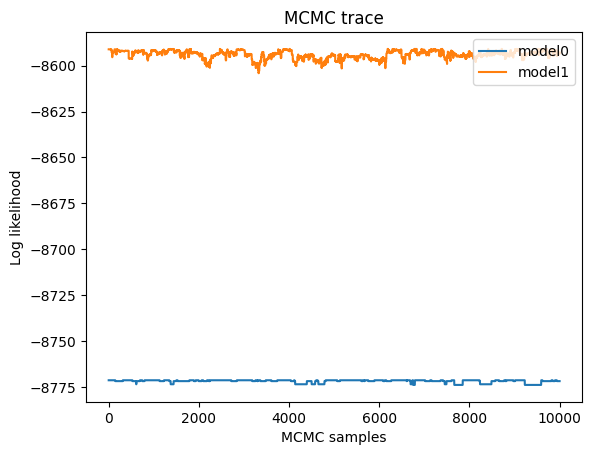

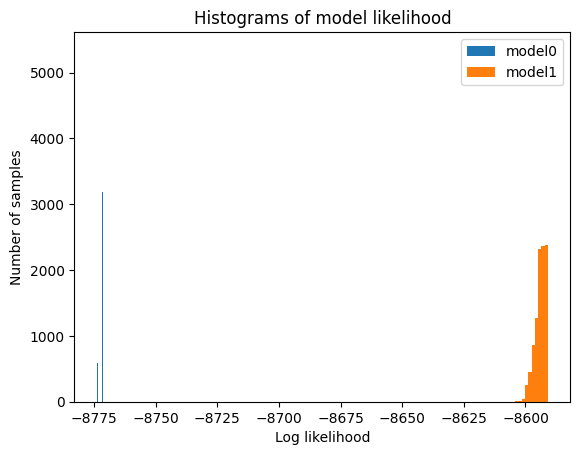

In [70]:
# for each subtype model
for s in range(N_S_max):
    # load pickle file (SuStaIn output) and get the sample log likelihood values
    pickle_filename_s = output_folder + '/pickle_files/' + dataset_name + '_subtype' + str(s) + '.pickle'
    pk = pandas.read_pickle(pickle_filename_s)
    samples_likelihood = pk["samples_likelihood"]
    
    # plot the values as a line plot
    fig0 = plt.figure(0)
    plt.plot(range(N_iterations_MCMC), samples_likelihood, label="model" + str(s))
    plt.legend(loc='upper right')
    plt.xlabel('MCMC samples')
    plt.ylabel('Log likelihood')
    plt.title('MCMC trace')
    
    # plot the values as a histogramp plot
    fig1 = plt.figure(1)
    plt.hist(samples_likelihood, label="model" + str(s))
    plt.legend(loc='upper right')
    plt.xlabel('Log likelihood')  
    plt.ylabel('Number of samples')  
    plt.title('Histograms of model likelihood')
fig0.savefig(output_folder+'/mcmc_trace.png')
fig1.savefig(output_folder+'/mcmc_histogram.png')


0
[1.]
[0]
1
[0.54331117 0.45668883]
[1 0]


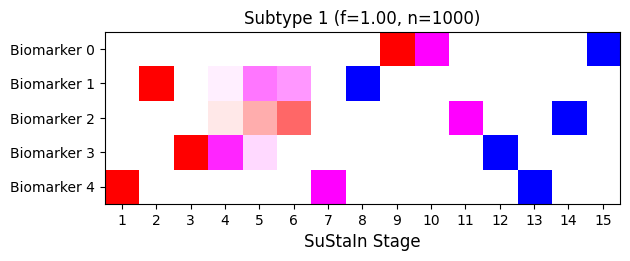

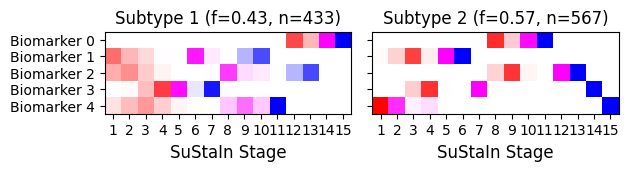

In [69]:
# Let's plot positional variance diagrams to interpret the subtype progressions
use_outlier = False
for s in range(N_S_max):
    print(s)
    #s = 1 # 1 split = 2 subtypes
    M = len(X_data) 

    # get the sample sequences and f
    pickle_filename_s = output_folder + '/pickle_files/' + dataset_name + '_subtype' + str(s) + '.pickle'
    pk = pandas.read_pickle(pickle_filename_s)
    samples_sequence = pk["samples_sequence"]
    samples_f = pk["samples_f"]
    ml_f_EM = pk["ml_f_EM"]
    print(ml_f_EM)
    if use_outlier:
        subtype_order = np.argsort(ml_f_EM[:-1])
    else:
        subtype_order = np.argsort(ml_f_EM)
    print(subtype_order)
    # use this information to plot the positional variance diagrams
    tmp=ZscoreSustain_APOE4._plot_sustain_model(sustain_input,samples_sequence,samples_f,M,subtype_order=subtype_order,biomarker_labels=BiomarkerNames)
    plt.savefig(output_folder + f"/pos_var_diagrams{s}.png")